<a href="https://colab.research.google.com/github/PratikshaShind/OASIS-INFOBYTE/blob/main/PratikshaShinde_Task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Missing Values Check ---
Area_SqFt    25
Rooms         0
Age_Years    25
Location      0
Price         0
dtype: int64

--- Descriptive Statistics ---
         Area_SqFt       Rooms   Age_Years          Price
count   475.000000  500.000000  475.000000     500.000000
mean   2004.650526    3.488000   25.341053  355765.956615
std     487.835727    1.101036   14.019031   84787.653850
min     379.000000    2.000000    0.000000   96484.836811
25%    1660.000000    3.000000   13.000000  302855.804661
50%    2012.000000    4.000000   26.000000  354086.870069
75%    2319.000000    4.000000   37.000000  413653.997762
max    3926.000000    5.000000   49.000000  690952.480249


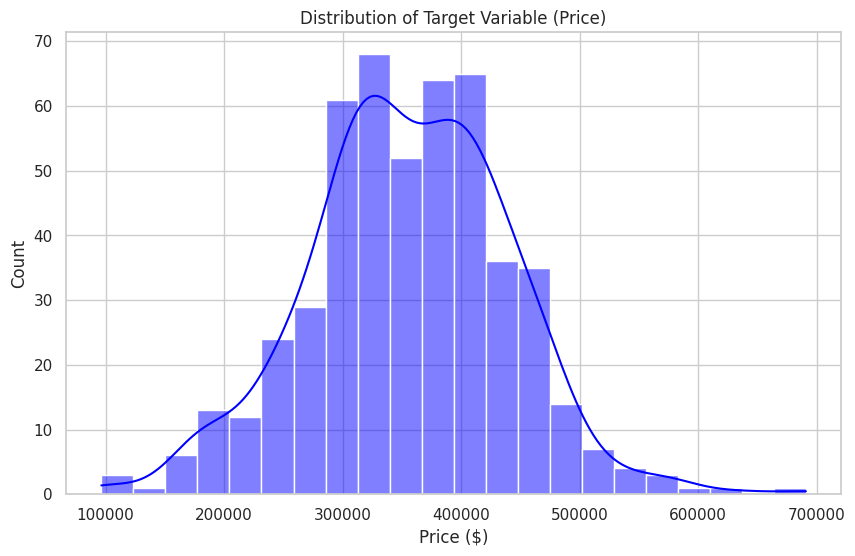

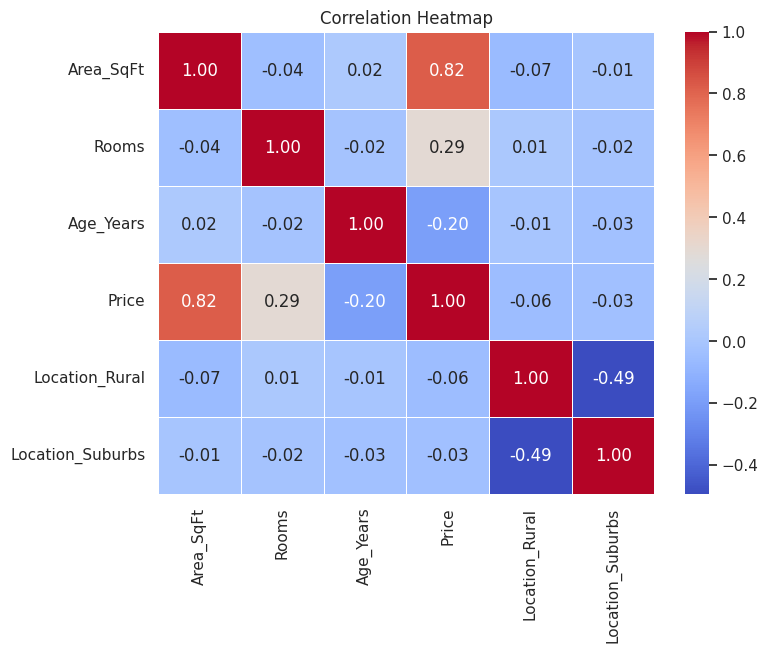


--- Linear Regression Performance ---
Mean Squared Error (MSE)      : 990686173.60
Root Mean Squared Error (RMSE): 31475.17
R² Score                      : 0.8636


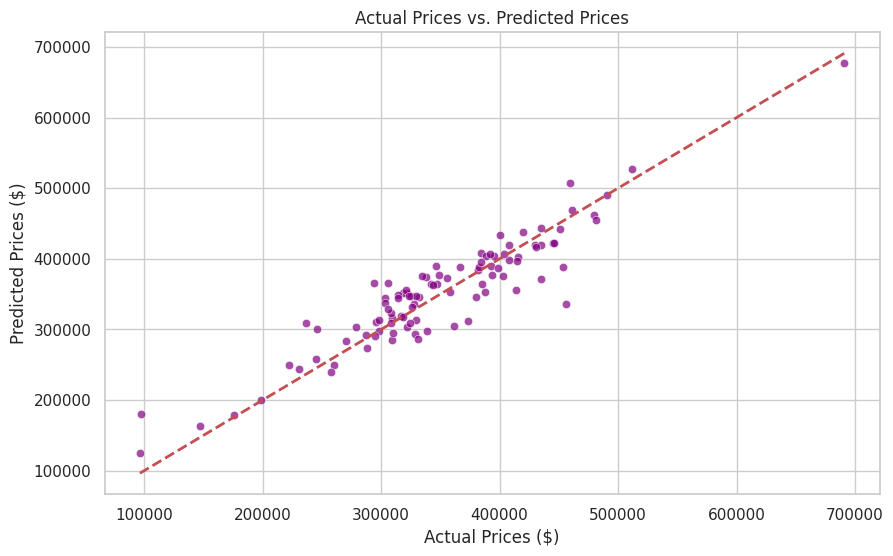

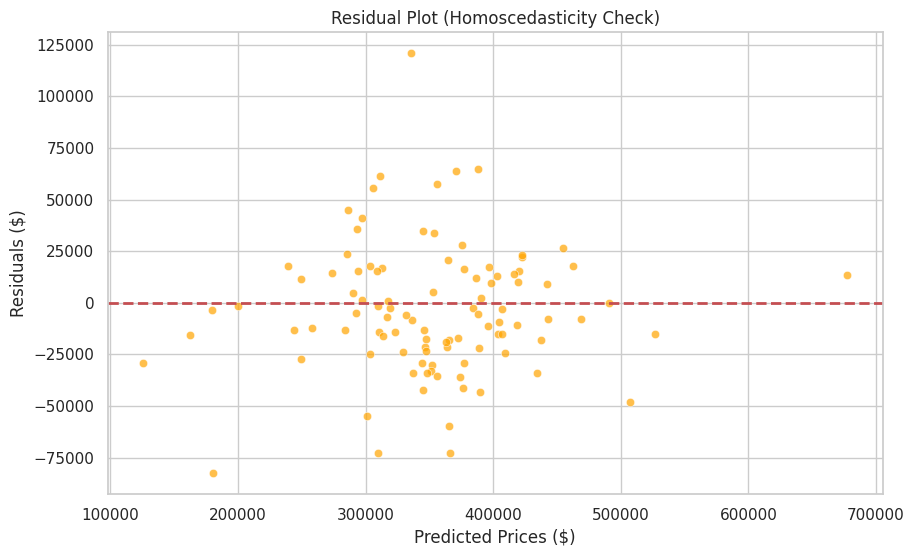


--- Feature Impact Analysis ---
         Feature  Coefficient
           Rooms 25347.680386
       Area_SqFt   147.811550
       Age_Years -1248.909179
  Location_Rural -3909.174430
Location_Suburbs -7669.993033

--- Ridge Regression Performance (Alpha=1.0) ---
Ridge RMSE: 31469.56
Ridge R²  : 0.8637


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Set styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Generate synthetic dataset mimicking typical real estate data (Ames style)
np.random.seed(42)
n_samples = 500

data = {
    'Area_SqFt': np.random.normal(2000, 500, n_samples).astype(int),
    'Rooms': np.random.randint(2, 6, n_samples),
    'Age_Years': np.random.randint(0, 50, n_samples),
    'Location': np.random.choice(['Downtown', 'Suburbs', 'Rural'], n_samples)
}

df = pd.DataFrame(data)
# Corrected: Calculate Price column directly using vectorized operations
df['Price'] = (df['Area_SqFt'] * 150) + \
              (df['Rooms'] * 25000) - \
              (df['Age_Years'] * 1200) + \
              np.random.normal(0, 30000, n_samples)

# Introduce a few missing values to test the data cleaning step
df.loc[df.sample(frac=0.05).index, 'Area_SqFt'] = np.nan
df.loc[df.sample(frac=0.05).index, 'Age_Years'] = np.nan


print("--- Missing Values Check ---")
print(df.isnull().sum())
print("\n--- Descriptive Statistics ---")
print(df.describe())

# Plot Target Variable Distribution
plt.figure()
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Target Variable (Price)')
plt.xlabel('Price ($)')
plt.show()


"""
Feature Selection Strategy:
- Area_SqFt: Continuous numeric variable. Strongest linear predictor of price in structural valuation.
- Rooms: Discrete numeric variable. Reflects layout capacity and strongly influences buyer intent.
- Age_Years: Numeric variable. Depreciates property values over time due to structural wear.
- Location: Categorical variable. Represents structural spatial premium (e.g., Downtown vs. Rural).
"""


num_cols = ['Area_SqFt', 'Rooms', 'Age_Years']
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Encode Categorical Features using One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Location'], drop_first=True)

# Generate Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


# Separate Features and Target
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

# 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Linear Regression Performance ---")
print(f"Mean Squared Error (MSE)      : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score                      : {r2:.4f}")


plt.figure()
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual Prices vs. Predicted Prices')
plt.xlabel('Actual Prices ($)')
plt.ylabel('Predicted Prices ($)')
plt.show()

# Residual Plot
residuals = y_test - y_pred
plt.figure()
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, color='orange')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Residual Plot (Homoscedasticity Check)')
plt.xlabel('Predicted Prices ($)')
plt.ylabel('Residuals ($)')
plt.show()


coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Feature Impact Analysis ---")
print(coefficients.to_string(index=False))


ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_ridge_pred = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_ridge_pred))
ridge_r2 = r2_score(y_test, y_ridge_pred)

print("\n--- Ridge Regression Performance (Alpha=1.0) ---")
print(f"Ridge RMSE: {ridge_rmse:.2f}")
print(f"Ridge R²  : {ridge_r2:.4f}")